# Student Performance Data Analysis

## Objective
The goal of this project is to analyze student performance data and understand how different factors such as gender, parental education, lunch type, and test preparation course affect academic performance in math, reading, and writing.


# Step 1: Import Libraries + Load Data

In [40]:
import pandas as pd

# Load CSV
df = pd.read_csv("../data/student_performance.csv")

# Show first 5 rows
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Dataset Overview and Cleaning

We first examine the dataset structure, data types, and check for missing values to ensure data quality before analysis.


In [41]:
# checks rows and columns
df.shape

# check column names and data types
df.info()

# Check for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [42]:
# Show summary statistics for numerical columns
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Distribution of Student Scores

The distributions show how student scores are spread across math, reading, and writing subjects.


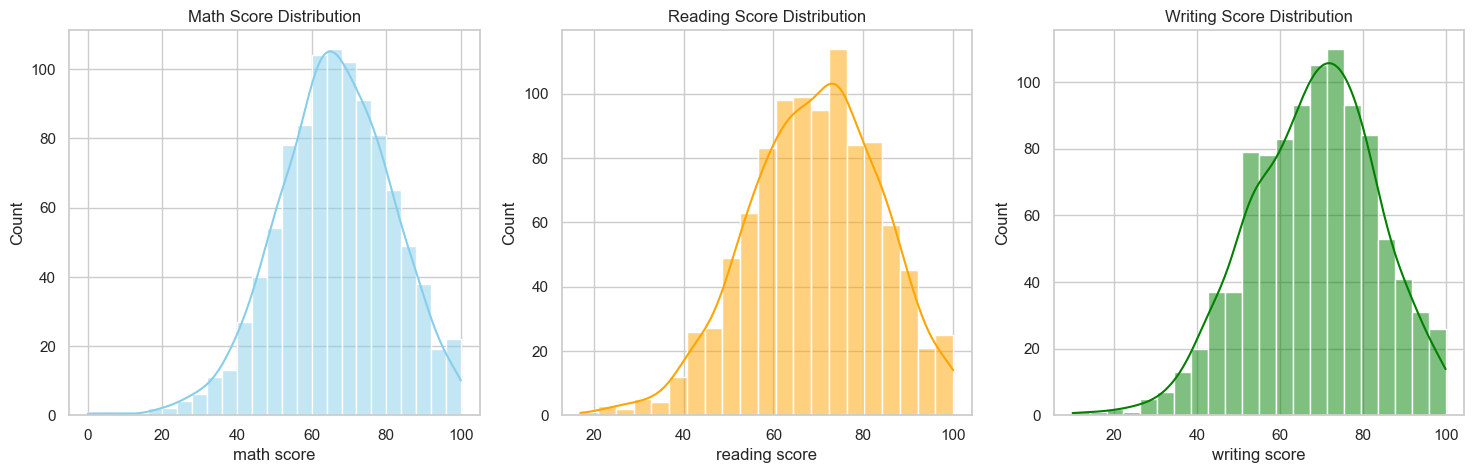

In [43]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Plot histograms for each subject separately

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.histplot(df['math score'], kde=True, color='skyblue')
plt.title("Math Score Distribution")

plt.subplot(1,3,2)
sns.histplot(df['reading score'], kde=True, color='orange')
plt.title("Reading Score Distribution")

plt.subplot(1,3,3)
sns.histplot(df['writing score'], kde=True, color='green')
plt.title("Writing Score Distribution")

plt.show()


## Impact of Test Preparation Course

Students who completed the test preparation course show higher average scores across all subjects compared to those who did not.


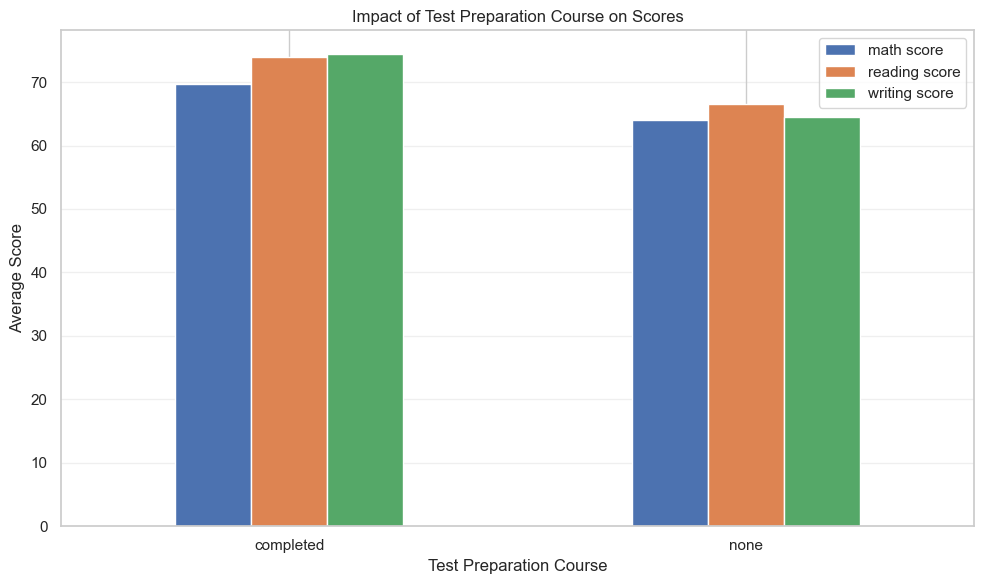

In [44]:
import matplotlib.pyplot as plt

prep_scores = df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean()

prep_scores

prep_scores.plot(kind='bar', figsize=(10,6))
plt.title("Impact of Test Preparation Course on Scores")
plt.ylabel("Average Score")
plt.xlabel("Test Preparation Course")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



## Performance Comparison by Gender

The analysis shows noticeable differences in average scores between male and female students across subjects.


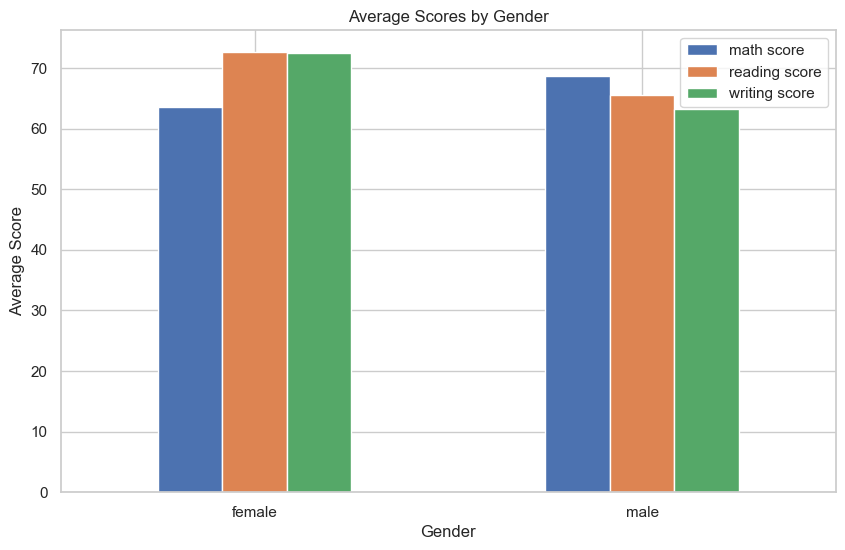

In [45]:
gender_scores = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()

gender_scores.plot(kind='bar', figsize=(10,6))
plt.title("Average Scores by Gender")
plt.ylabel("Average Score")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.show()


## Correlation Between Subject Scores

- There is a strong positive correlation between reading and writing scores.
- Math scores are also positively correlated with reading and writing, but slightly weaker.
- This indicates that language-related skills are closely connected.


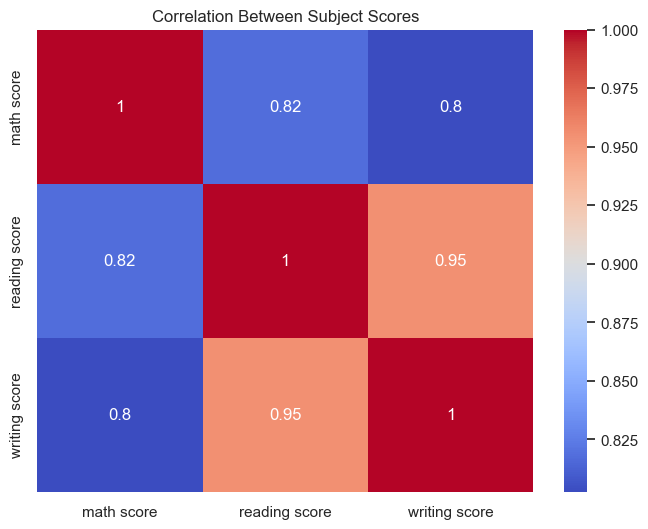

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    df[['math score', 'reading score', 'writing score']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Between Subject Scores")
plt.show()


## Parental Education and Student Performance

Students whose parents have higher educational qualifications tend to score higher on average.  
This suggests that parental academic background may positively influence students’ learning environment and performance.



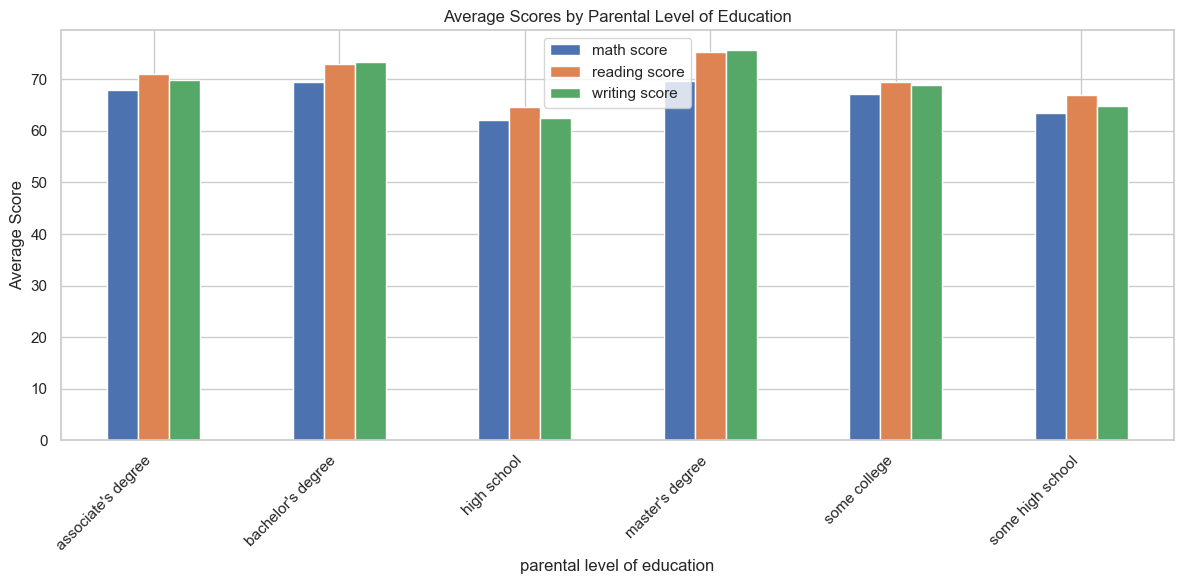

In [47]:
avg_parent_edu = df.groupby('parental level of education')[['math score','reading score','writing score']].mean()

avg_parent_edu.plot(kind='bar', figsize=(12,6))

plt.title("Average Scores by Parental Level of Education")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Impact of Lunch Type on Student Performance

- Students with a **standard lunch** consistently score higher in math, reading, and writing.
- Students receiving **free/reduced lunch** show lower average scores across all subjects.
- This suggests that economic factors and access to nutrition may influence academic performance.

Students receiving standard lunch generally perform better than those receiving free or reduced lunch, suggesting a possible relationship between socioeconomic status and academic performance.


<Figure size 800x600 with 0 Axes>

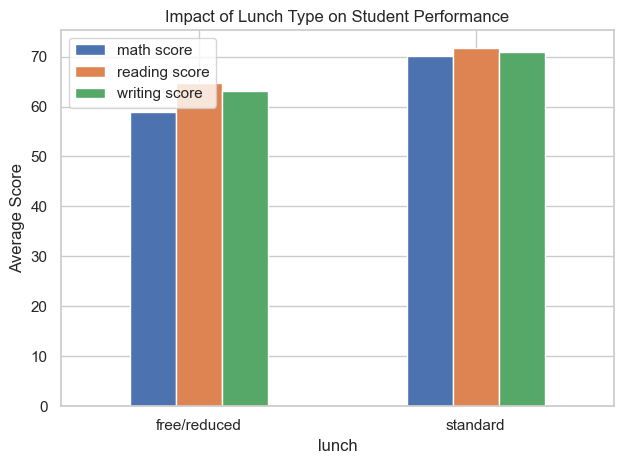

In [48]:
plt.figure(figsize=(8,6))

avg_lunch = df.groupby('lunch')[['math score','reading score','writing score']].mean()

avg_lunch.plot(kind='bar')

plt.title("Impact of Lunch Type on Student Performance")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
